1. Importing Necessary Libraries

In [1]:
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd, numpy as np

2. Auto-save Matplotlib Figures (PNG + PDF)

In [2]:
# Monkey-patch `plt.show()` so every figure is automatically saved to PNG and, optionally, appended to a single PDF report. Great for evaluation notebooks
# where each `plt.show()` should also produce an artifact on disk.        
# 1) Run this cell at the TOP of your notebook (before generating any plots).
# 2) Create plots as usual: plt.figure(), plt.plot(...), plt.show().
# 3) Each call to plt.show() will auto-save the current figure to: OUT_DIR / f"{FILE_PREFIX}_{NN}.png" and also append it to a PDF report (if MAKE_PDF=True).
# 4) Run `finalize_autosave()` ONCE at the end to close the PDF and print a summary.

# Output configuration
#OUT_DIR = Path("./eval_detector_viz")                      # Folder where images/PDF will be stored
#OUT_DIR = Path("./eval_detector_unknown_fgsm_RNN_viz")      # Folder where images/PDF will be stored  
OUT_DIR = Path("./eval_detector_unknown_PGD_viz")      # Folder where images/PDF will be stored  
FILE_PREFIX = "eval"                                        # Prefix for sequential PNG filenames
MAKE_PDF = True                                             # True => also build a single PDF report

# Ensure output folder exists
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Internal state (kept minimal and explicit) 
__fig_counter = {'i': 0}    # simple mutable counter (dict to avoid 'nonlocal')
__orig_show = plt.show      # keep original plt.show reference
__pdf = {'obj': PdfPages(OUT_DIR / f"evaluation_visual_report_{datetime.now().strftime('%Y%m%d-%H%M%S')}.pdf")} if MAKE_PDF else {'obj': None}

def _save_current_fig():
    """Save the most recent matplotlib figure to PNG and optionally to the PDF.

    Notes:
        - Uses the last figure number from plt.get_fignums().
        - PNG filenames are sequential: {FILE_PREFIX}_01.png, _02.png, ...
        - PDF appending is enabled only when MAKE_PDF=True.
    """
    fignums = plt.get_fignums()
    if not fignums:
        return
    num = fignums[-1]        # last created/active figure         
    fig = plt.figure(num)  

    __fig_counter['i'] += 1
    fname = f"{FILE_PREFIX}_{__fig_counter['i']:02d}.png"
    fig.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")

    if __pdf['obj'] is not None:
        __pdf['obj'].savefig(fig)

def _show_and_save(*args, **kwargs):
    """Replacement for plt.show() that saves the figure before showing it.

    Rationale:
        Saving BEFORE showing ensures we capture the final state even if
        backends clear or alter figures after display.
    """
    _save_current_fig()
    return __orig_show(*args, **kwargs)

# Enable auto-save by monkey-patching plt.show 
plt.show = _show_and_save

def finalize_autosave():
    """Close the PDF (if any) and print a short summary.

    Call this ONCE at the end of the notebook to flush/close the PDF file.
    """
    if __pdf['obj'] is not None:
        try:
            __pdf['obj'].close()
            print("PDF saved.")
        except Exception as e:
            print("⚠ Error while closing PDF:", e)
    print(f"[AutoSave] Saved {__fig_counter['i']} PNG(s)  to:", OUT_DIR)

print(f"[AutoSave] Enabled. PNGs => {OUT_DIR}, PDF => {MAKE_PDF}")


[AutoSave] Enabled. PNGs => eval_detector_unknown_PGD_viz, PDF => True


3. Summary Locator Helper 

In [3]:
# Define CLASS_NAMES and robustly locate the Excel summary file.
# CLASS_NAMES order matters if you index by class id.
# This helper is silent except for a short status print.

# Project class names (order matters if you index by class id) 
CLASS_NAMES = ['clean', 'adversarial']

# Try to resolve the Excel summary in the current directory 
#DEFAULT_SUMMARY = Path('.') / 'evaluation_detector_summary.xlsx'
#DEFAULT_SUMMARY = Path('.') / 'evaluation_detector_unknown_fgsm_RNN_summary.xlsx'
DEFAULT_SUMMARY = Path('.') / 'evaluation_detector_unknown_PGD_summary.xlsx'
if DEFAULT_SUMMARY.exists():
    SUMMARY_PATH = DEFAULT_SUMMARY
else:
    # Look for any file literally named 'evaluation_summary.xlsx' in '.'
    #candidates = list(Path('.').glob('evaluation_detector_summary.xlsx'))
    #candidates = list(Path('.').glob('evaluation_detector_unknown_fgsm_RNN_summary.xlsx'))
    candidates = list(Path('.').glob('evaluation_detector_unknown_PGD_summary.xlsx'))
    # Pick the most recently modified, or fall back to a placeholder path
    #SUMMARY_PATH = max(candidates, key=lambda p: p.stat().st_mtime) if candidates else Path(r'C:/Users/evri/Desktop/Διπλωματικη/Adversarial AI Attack Detection/Adversarial-AI-Attack-Detection/evaluation_detector_summary.xlsx')
    #SUMMARY_PATH = max(candidates, key=lambda p: p.stat().st_mtime) if candidates else Path(r'C:/Users/evri/Desktop/Διπλωματικη/Adversarial AI Attack Detection/Adversarial-AI-Attack-Detection/evaluation_detector_unknown_fgsm_RNN_summary.xlsx')
    SUMMARY_PATH = max(candidates, key=lambda p: p.stat().st_mtime) if candidates else Path(r'C:/Users/evri/Desktop/Διπλωματικη/Adversarial AI Attack Detection/Adversarial-AI-Attack-Detection/evaluation_detector_unknown_PGD_summary.xlsx')

# Short status output for sanity checks 
print('SUMMARY_PATH:', SUMMARY_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

SUMMARY_PATH: evaluation_detector_unknown_PGD_summary.xlsx
CLASS_NAMES: ['clean', 'adversarial']


4. Read Evaluation Summary Sheets (Excel)

In [4]:
# Utility to read the core sheets from `evaluation_summary.xlsx`:
# - "Summary"      (required)
# - "TP_TN_FP_FN"     (optional)
# - "Confusions"   (optional)
# Uses openpyxl when available and falls back gracefully if not.

def read_summary_sheets(xlsx_path: Path):
    """Read the main evaluation sheets from the summary Excel file.

    Attempts to use the 'openpyxl' engine first for compatibility, and falls
    back to pandas' default engine if 'openpyxl' is not installed.

    Args:
        xlsx_path: Path to the Excel file (e.g., Path("evaluation_summary.xlsx")).

    Returns:
        A tuple of:
            - df_summary: Required dataframe for the "Summary" sheet.
            - df_tpfp: Optional dataframe for the "TP_TN_FP_FN" sheet (or None if missing).
            - df_cm: Optional dataframe for the "Confusions" sheet (or None if missing).
    """
    # Summary (required) 
    try:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary', engine='openpyxl')
    except Exception:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary')

    # TP_TN_FP_FN (optional)
    try:
        df_tpfp = pd.read_excel(xlsx_path, sheet_name='TP_TN_FP_FN', engine='openpyxl')
    except Exception:
        try:
            df_tpfp = pd.read_excel(xlsx_path, sheet_name='TP_TN_FP_FN')
        except Exception:
            df_tpfp = None

    # Confusions (optional) 
    try:
        df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions', engine='openpyxl')
    except Exception:
        try:
            df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions')
        except Exception:
            df_cm = None

    return df_summary, df_tpfp, df_cm

# Execute & quick peek (notebook-friendly)
# Reads the sheets from SUMMARY_PATH and displays a small preview so you can verify content.
df_summary, df_tpfp, df_cm = read_summary_sheets(SUMMARY_PATH)

print('Summary head:'); 
display(df_summary.head())

print("TP_TN_FP_FN head:" if df_tpfp is not None else "No 'TP_TN_FP_FN' sheet found.")
display(df_tpfp.head()) if df_tpfp is not None else None

print('Confusions head:' if df_cm is not None else "No 'Confusions' sheet found (optional).")
display(df_cm.head()) if df_cm is not None else None

Summary head:


,model,n_samples,accuracy,precision,recall,f1,roc_auc,pr_auc
0,ANN,23198,0.628330,0.985328,0.260540,0.412110,0.794184,0.832642
1,CNN,23198,0.974955,0.999909,0.949996,0.974314,0.999713,0.999735
2,RNN,23198,0.813174,0.992676,0.631003,0.771558,0.960255,0.968383
3,SEMI_CNN,23198,0.994353,0.998349,0.990344,0.994330,0.999941,0.999941
4,SEMI_CNN_LIFELONG,23198,0.997370,0.994853,0.999914,0.997377,0.999999,0.999999


TP_TN_FP_FN head:


,model,TP,TN,FP,FN
0,ANN,3022,11554,45,8577
1,CNN,11019,11598,1,580
2,RNN,7319,11545,54,4280
3,SEMI_CNN,11487,11580,19,112
4,SEMI_CNN_LIFELONG,11598,11539,60,1


Confusions head:


,model,true,pred,count
0,ANN,clean,clean,11554
1,ANN,clean,attack,45
2,ANN,attack,clean,8577
3,ANN,attack,attack,3022
4,CNN,clean,clean,11598


5. Aggregations: Per-Model Accuracy / Precision / Recall

In [5]:
# Produce simple per-model pivots and styled displays from `df_summary`.

# Accuracy by Model
pv_acc = (
    df_summary
    .groupby('model', dropna=False)['accuracy']
    .mean()                        
    .to_frame(name='accuracy')
    .sort_index()
)
display(pv_acc.style.format('{:.4f}').set_caption('Accuracy by Model'))

# precision by Model  
pv_precision = (
    df_summary
    .groupby('model', dropna=False)['precision']
    .mean()
    .to_frame(name='precision')
    .sort_index()
)
display(pv_precision.style.format('{:.4f}').set_caption('precision by Model'))

# 3) pv_ece by Model  
pv_recall = (
    df_summary
    .groupby('model', dropna=False)['recall']
    .mean()
    .to_frame(name='recall')
    .sort_index()
)
display(pv_recall.style.format('{:.4f}').set_caption('recall by Model'))


,accuracy
model,
ANN,0.6283
CNN,0.9750
RNN,0.8132
SEMI_CNN,0.9944
SEMI_CNN_LIFELONG,0.9974


,precision
model,
ANN,0.9853
CNN,0.9999
RNN,0.9927
SEMI_CNN,0.9983
SEMI_CNN_LIFELONG,0.9949


,recall
model,
ANN,0.2605
CNN,0.9500
RNN,0.6310
SEMI_CNN,0.9903
SEMI_CNN_LIFELONG,0.9999


6. Visualization: Grouped Bar Charts by Dataset

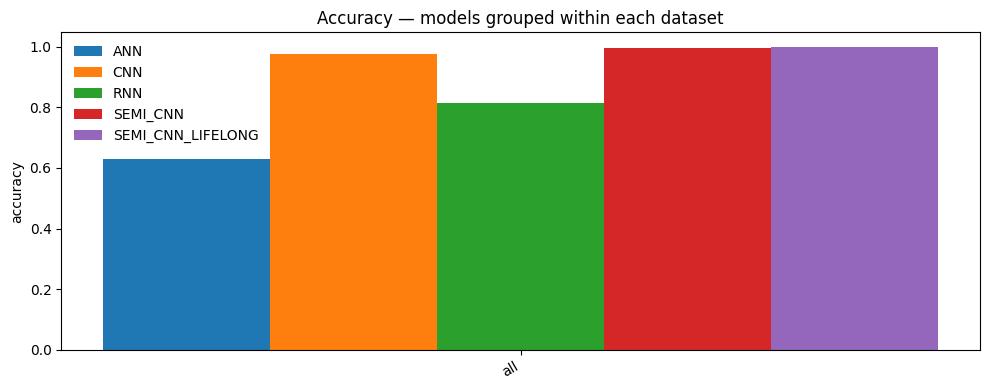

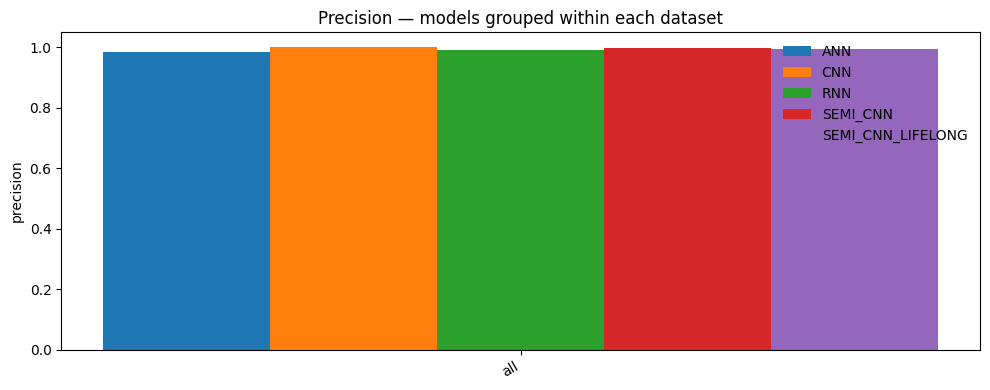

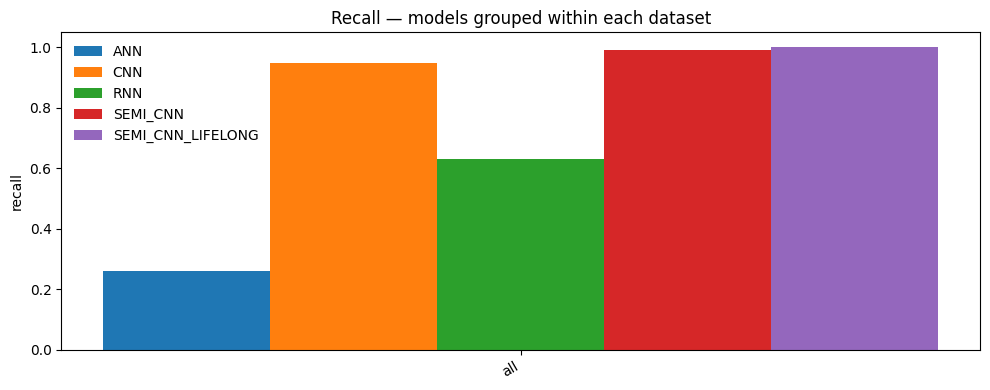

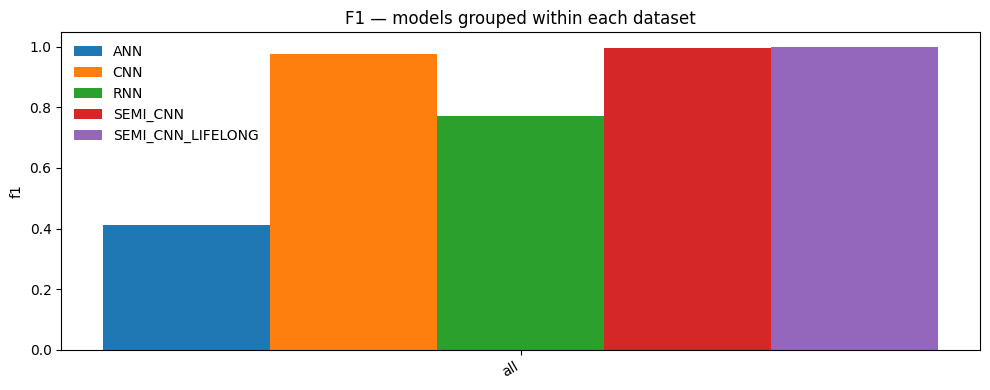

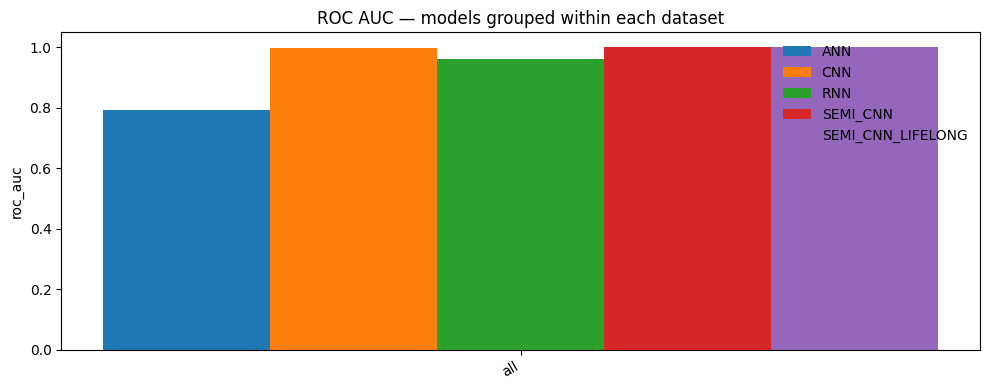

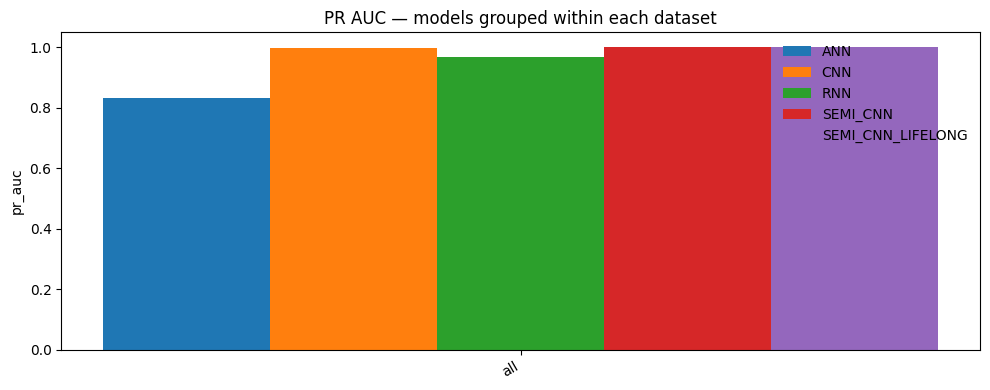

In [6]:
# Plot grouped bar charts for a chosen metric across datasets, with bars grouped by model.

def grouped_bars(metric_col: str, title: str, df_src=None):
    """
    Plot grouped bars for one metric, grouped by model.

    Parameters
    ----------
    metric_col : str
        One of {'accuracy','precision','recall','f1','roc_auc','pr_auc'}.
    title : str
        Figure title.
    df_src : pd.DataFrame or None
        Source summary dataframe. If None, uses global `df_summary`.

    Expected columns
    ----------------
    - 'model' (either as a column or index)
    - one metric column (any alias listed below)
    - optional dataset column like 'dataset'/'task'/'domain'/'set'/'corpus'/'source'
    """
    # Use provided df or fall back to global
    df = (df_src if df_src is not None else df_summary).copy()

    # Normalize column names (lowercase, strip)
    df.columns = [str(c).strip().lower() for c in df.columns]

    # Ensure 'model' is a column (not only index)
    if 'model' not in df.columns and ('model' in (df.index.names or [])):
        df = df.reset_index()
    if 'model' not in df.columns:
        raise KeyError("Missing 'model' column or index.")

    # Find or create dataset column
    ds_col = next((c for c in ['dataset','task','domain','set','corpus','source'] if c in df.columns), None)
    if ds_col is None:
        df['dataset'] = 'all'
        ds_col = 'dataset'

    # Resolve metric aliases to an existing column
    aliases = {
        'accuracy': ['accuracy','acc','top1','top_1','acc1','top1_acc','top-1'],
        'precision': ['precision','prec','ppv'],
        'recall': ['recall','tpr','sensitivity','rec'],
        'f1': ['f1','f1_score','f1-score'],
        'roc_auc': ['roc_auc','auroc','roc-auc','auc_roc','rocauc'],
        'pr_auc': ['pr_auc','average_precision','aupr','ap','pr-auc','avg_precision'],
    }
    candidate_cols = aliases.get(metric_col, [metric_col])
    mcol = next((c for c in candidate_cols if c in df.columns), None)
    if mcol is None:
        print(f"⚠️ No column found for '{metric_col}'. Available: {list(df.columns)}")
        return

    # Coerce to numeric & aggregate in case of duplicates
    df[mcol] = pd.to_numeric(df[mcol], errors='coerce')
    df = (
        df.groupby(['model', ds_col], dropna=False, as_index=False)[mcol]
          .mean()
    )

    # Plot grouped bars
    models = sorted(df['model'].astype(str).unique())
    datasets = sorted(df[ds_col].astype(str).unique())

    width = 0.8 / max(len(models), 1)  # total width per dataset = 0.8
    x = np.arange(len(datasets))
    plt.figure(figsize=(max(10, 1.4 * len(datasets)), 4))

    for i, m in enumerate(models):
        sub = df[df['model'] == m].set_index(ds_col).reindex(datasets)
        vals = sub[mcol].values
        plt.bar(x + i * width, vals, width, label=m)

    plt.xticks(x + width * (len(models) - 1) / 2, datasets, rotation=30, ha='right')
    plt.ylabel(metric_col)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Example calls for the requested columns 
grouped_bars('accuracy',  'Accuracy — models grouped within each dataset')
grouped_bars('precision', 'Precision — models grouped within each dataset')
grouped_bars('recall',    'Recall — models grouped within each dataset')
grouped_bars('f1',        'F1 — models grouped within each dataset')
grouped_bars('roc_auc',   'ROC AUC — models grouped within each dataset')
grouped_bars('pr_auc',    'PR AUC — models grouped within each dataset')


7. Visualization: TP/FP/FN/TN Stacked Bars

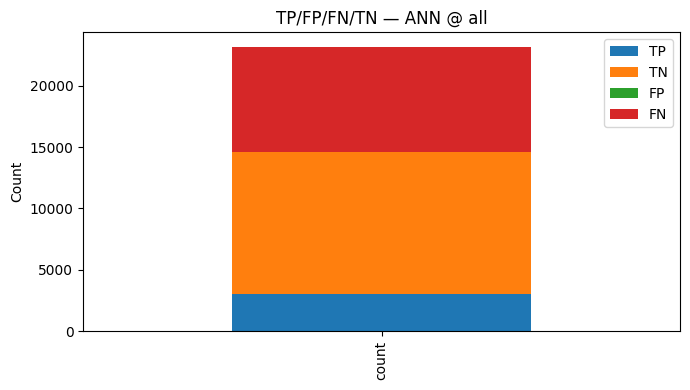

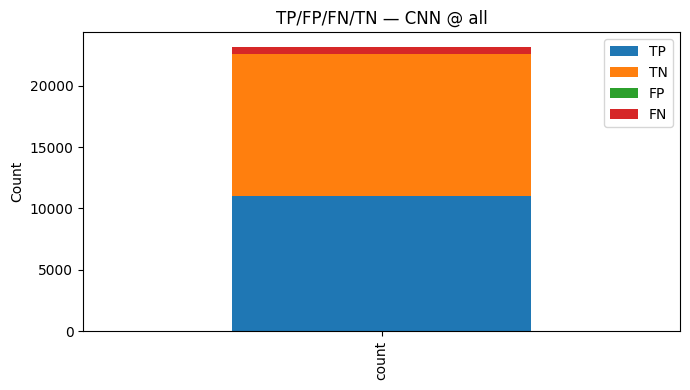

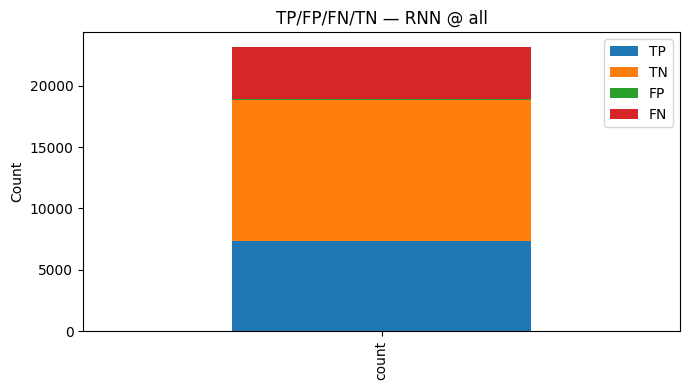

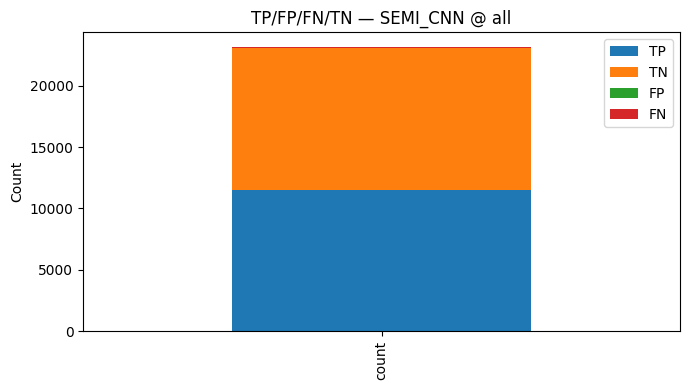

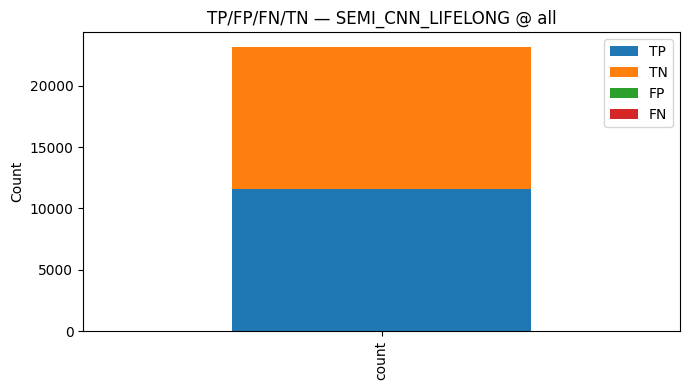

In [7]:
# Plot per-model stacked bars of TP/TN/FP/FN. 
# - df_tpfp: DataFrame with columns ['model', 'TP', 'TN', 'FP', 'FN'] 

# 1) Make a safe copy and normalize column names to lowercase.
# 2) Validate required columns (model, tp, tn, fp, fn).
# 3) Ensure a 'dataset' column exists; if not, synthesize 'all'.
# 4) Aggregate duplicates per (model, dataset) by summing counts.
# 5) Define a small helper that draws a single stacked bar for one (model, dataset).
# 6) Iterate over all unique (model, dataset) pairs and plot.



# Make a safe copy and normalize column names (lowercase) 
_df_tpfp = df_tpfp.copy()
_df_tpfp.columns = [str(c).strip().lower() for c in _df_tpfp.columns]

# Ensure required columns exist 
required = {'model', 'tp', 'tn', 'fp', 'fn'}
missing = required - set(_df_tpfp.columns)
if missing:
    raise KeyError(f"Missing columns in df_tpfp: {missing}. Got: {list(_df_tpfp.columns)}")

# Ensure a 'dataset' column exists; synthesize if absent 
if 'dataset' not in _df_tpfp.columns:
    _df_tpfp['dataset'] = 'all'

# Optionally aggregate duplicates (same model & dataset) 
_df_tpfp = (
    _df_tpfp
    .groupby(['model', 'dataset'], as_index=False)[['tp','tn','fp','fn']]
    .sum()
)

def plot_tpfp_for(model: str, dataset: str):
    """Plot a single stacked bar (TP/TN/FP/FN) for a given (model, dataset)."""
    sub = _df_tpfp[(_df_tpfp['model'].astype(str) == str(model)) &
                   (_df_tpfp['dataset'].astype(str) == str(dataset))]
    if sub.empty:
        print(f"⚠️ No rows for model={model}, dataset={dataset}")
        return

    # Sum counts in case multiple rows remain after filtering
    row = sub[['tp','tn','fp','fn']].sum()
    counts = row.rename(index={'tp':'TP','tn':'TN','fp':'FP','fn':'FN'})

    # Single stacked bar (TP/TN/FP/FN)
    counts.to_frame(name='count').T.plot(
        kind='bar', stacked=True, figsize=(7, 4),
        title=f'TP/FP/FN/TN — {model} @ {dataset}', legend=True
    )
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Plot for each (model, dataset) combo 
combos = _df_tpfp[['model','dataset']].drop_duplicates().values
for model, dataset in combos:
    plot_tpfp_for(model, dataset)

8. Confusion Matrices per (Model)

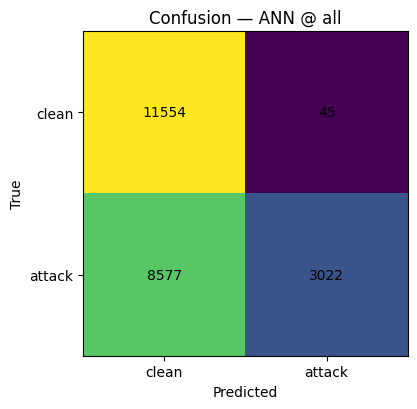

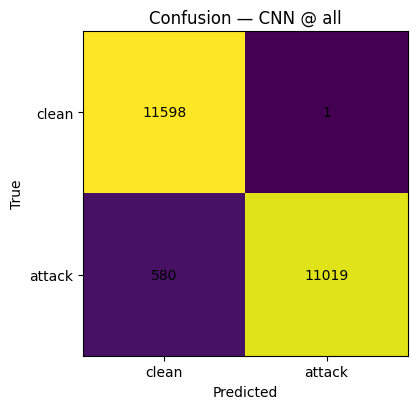

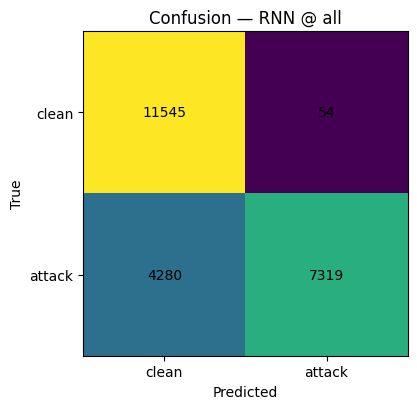

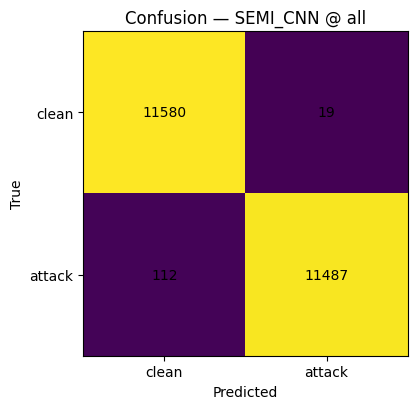

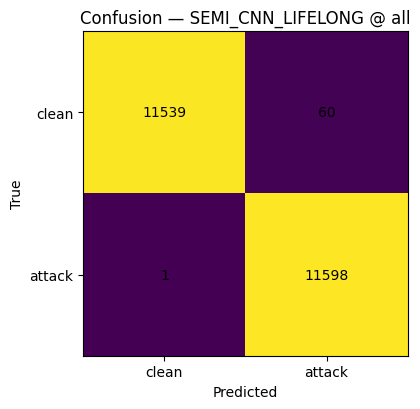

In [8]:
# Render 2×2 confusion matrices from the 'Confusions' sheet (df_cm),
# df_cm: DataFrame with columns ['model','true','pred','count'] and (optionally) 'dataset'
# If 'dataset' is missing, we synthesize a single group 'all'
# Class order defaults to ['clean','attack'] when available; otherwise uses discovered labels


# Safe copy & normalize column names 
_cm = df_cm.copy()
_cm.columns = [str(c).strip().lower() for c in _cm.columns]

# Validate required columns
required = {'model', 'true', 'pred', 'count'}
missing = required - set(_cm.columns)
if missing:
    raise KeyError(f"Missing columns in df_cm: {missing}. Got: {list(_cm.columns)}")

# Ensure a 'dataset' column exists (fallback to single 'all')
if 'dataset' not in _cm.columns:
    _cm['dataset'] = 'all'

# Coerce types 
_cm['count'] = pd.to_numeric(_cm['count'], errors='coerce').fillna(0).astype(int)
_cm['true']  = _cm['true'].astype(str)
_cm['pred']  = _cm['pred'].astype(str)

# Decide class order (prefer ['clean','attack'] if present) 
preferred = ['clean', 'attack']
unique_classes = sorted(set(_cm['true']).union(set(_cm['pred'])), key=str)
order = preferred if all(c in unique_classes for c in preferred) else unique_classes

def plot_cm_for(model: str, dataset: str, order=order):
    """Plot a 2×2 confusion matrix for the given (model, dataset)."""
    sub = _cm[
        (_cm['model'].astype(str) == str(model)) &
        (_cm['dataset'].astype(str) == str(dataset))
    ]
    if sub.empty:
        print(f"⚠️ No rows for model={model}, dataset={dataset}")
        return

    # Build matrix with the chosen order; fill missing with zeros
    mat_df = (
        sub.pivot_table(index='true', columns='pred', values='count', aggfunc='sum')
           .reindex(index=order, columns=order, fill_value=0)
    )
    mat = mat_df.to_numpy()

    # Plot
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(mat, interpolation='nearest')
    ax.set_xticks(range(len(order))); ax.set_yticks(range(len(order)))
    ax.set_xticklabels(order);        ax.set_yticklabels(order)
    ax.set_xlabel('Predicted');       ax.set_ylabel('True')
    ax.set_title(f'Confusion — {model} @ {dataset}')

    # Annotate counts (cell values)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, int(mat[i, j]), ha='center', va='center')

    plt.tight_layout()
    plt.show()

# Render for each (model, dataset) combo
for model, dataset in _cm[['model', 'dataset']].drop_duplicates().values:
    plot_cm_for(model, dataset, order=order)

9. Close PDF & Print Autosave Summary

In [ ]:
# Gracefully finalize the auto-save PDF and print a short summary.

# END OF NOTEBOOK: close PDF & print summary 
try:
    finalize_autosave()
except NameError:
    print("AutoSave dont run.")

PDF saved.
[AutoSave] Saved 16 PNG(s)  to: eval_detector_unknown_PGD_viz
